# Case Study - SABR and the Tariff Smile

In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize

In [5]:
DATAPATH = 'data/'

# --- Daily smile snapshots (April 2025, 21 trading days) ---
smile_daily = pd.read_excel(DATAPATH + 'swaption_smile_daily_2025.xlsx',
                            sheet_name='black_vol_pct', index_col=0, parse_dates=True)
fwd_daily = pd.read_excel(DATAPATH + 'swaption_smile_daily_2025.xlsx',
                          sheet_name='atm_forward', index_col=0, parse_dates=True)

# --- Daily swap rates (pct -> decimal, March-May) ---
swaps_raw = pd.read_excel(DATAPATH + 'sofr_swaps.xlsx', sheet_name='data')
swaps_raw = swaps_raw.rename(columns={'Unnamed: 0': 'date'})
swaps_raw['date'] = pd.to_datetime(swaps_raw['date'])
swaps_raw = swaps_raw.set_index('date')
rate_5y = swaps_raw.loc['2025-03-01':'2025-05-31', 5.0] / 100

# --- Daily ATM swaption vols (bp, March-May) ---
vol_ts = pd.read_excel(DATAPATH + 'swaption_vol_timeseries_2025.xlsx',
                       sheet_name='atm_vols', index_col=0, parse_dates=True)
vol_1y5y = vol_ts.loc['2025-03-01':'2025-05-31', '1Yx5Y']

# Align broad time series
common_dates = rate_5y.index.intersection(vol_1y5y.index)
rate_5y = rate_5y.loc[common_dates]
vol_1y5y = vol_1y5y.loc[common_dates]

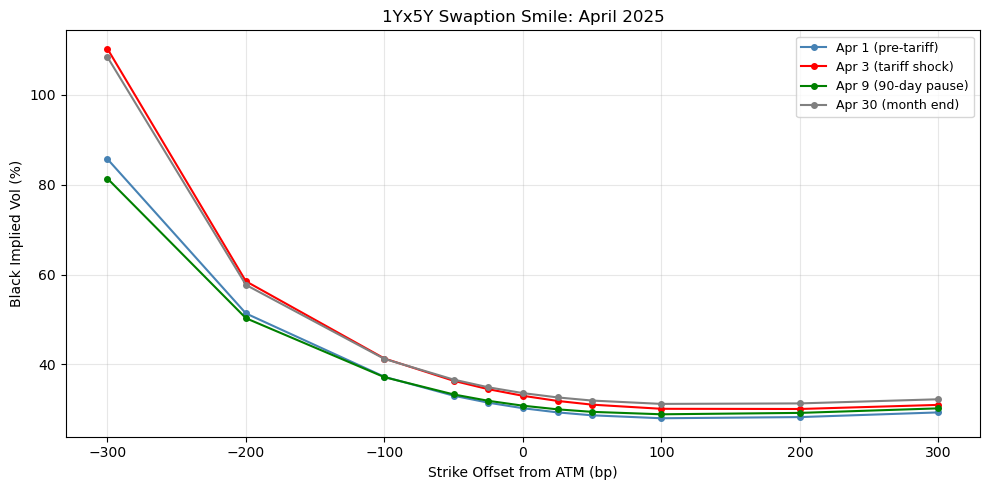

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

highlight_dates = ['2025-04-01', '2025-04-03', '2025-04-09', '2025-04-30']
colors = ['steelblue', 'red', 'green', 'gray']
labels = ['Apr 1 (pre-tariff)', 'Apr 3 (tariff shock)',
          'Apr 9 (90-day pause)', 'Apr 30 (month end)']

for dt_str, color, label in zip(highlight_dates, colors, labels):
    dt = pd.Timestamp(dt_str)
    if dt in smile_daily.index:
        offsets = smile_daily.columns.values.astype(int)
        vols = smile_daily.loc[dt].values
        ax.plot(offsets, vols, 'o-', color=color, label=label, markersize=4)

ax.set_xlabel('Strike Offset from ATM (bp)')
ax.set_ylabel('Black Implied Vol (%)')
ax.set_title('1Yx5Y Swaption Smile: April 2025')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

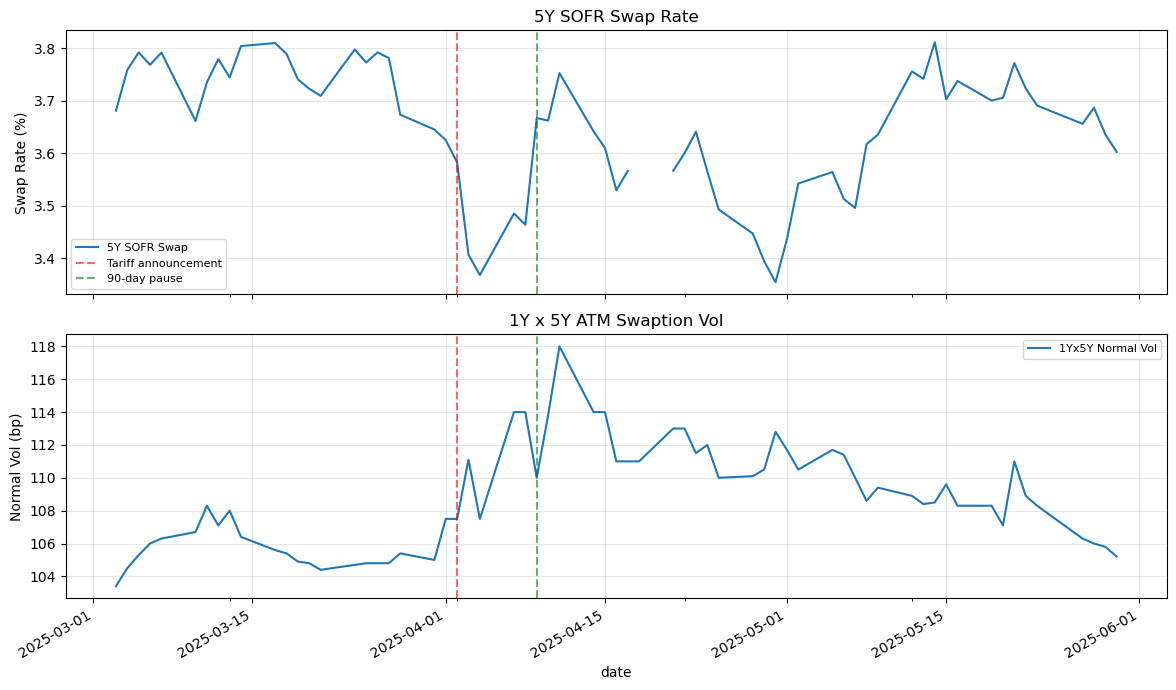

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1 = axes[0]
(rate_5y * 100).plot(ax=ax1, label='5Y SOFR Swap')
ax1.axvline(pd.Timestamp('2025-04-02'), color='red', linestyle='--', alpha=0.6, label='Tariff announcement')
ax1.axvline(pd.Timestamp('2025-04-09'), color='green', linestyle='--', alpha=0.6, label='90-day pause')
ax1.set_ylabel('Swap Rate (%)')
ax1.set_title('5Y SOFR Swap Rate')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
vol_1y5y.plot(ax=ax2, label='1Yx5Y Normal Vol')
ax2.axvline(pd.Timestamp('2025-04-02'), color='red', linestyle='--', alpha=0.6)
ax2.axvline(pd.Timestamp('2025-04-09'), color='green', linestyle='--', alpha=0.6)
ax2.set_ylabel('Normal Vol (bp)')
ax2.set_title('1Y x 5Y ATM Swaption Vol')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# --- Sanity checks ---
print("smile_daily shape:", smile_daily.shape)
print("smile_daily columns (first 10):", list(smile_daily.columns)[:10])
print("fwd_daily shape:", fwd_daily.shape)
print("fwd_daily columns:", list(fwd_daily.columns))

# --- Helper: coerce smile offset columns to numeric bp ---
def _coerce_bp_cols(cols):
    out = []
    for c in cols:
        # handle ints, floats, strings like "50", "+50", "50bp"
        if isinstance(c, (int, float)):
            out.append(float(c))
        else:
            s = str(c).lower().replace("bp", "").replace(" ", "").replace("+", "")
            out.append(float(s))
    return np.array(out, dtype=float)

bp_offsets = _coerce_bp_cols(smile_daily.columns)  # e.g. [-200, -150, ..., 200]

# --- Convert vols to decimals (if currently in %) ---
# You loaded from sheet_name='black_vol_pct', so these are likely percent.
smile_vol = smile_daily.copy()
if smile_vol.stack().dropna().median() > 1.0:   # heuristic: 50 means 50%
    smile_vol = smile_vol / 100.0

# --- Convert forwards to decimals (if in %) ---
# Often ATM forward sheet is in percent; convert if needed.
fwd = fwd_daily.copy()
# pick the first column if it's a 1-column df
fwd_col = fwd.columns[0] if fwd.shape[1] == 1 else None

if fwd_col is not None:
    if fwd[fwd_col].dropna().median() > 1.0:   # heuristic: 4.5 means 4.5%
        fwd[fwd_col] = fwd[fwd_col] / 100.0
else:
    pass

print("Median smile vol (dec):", float(smile_vol.stack().dropna().median()))
print("Median forward (dec):", float(fwd[fwd_col].dropna().median()))

smile_daily shape: (21, 11)
smile_daily columns (first 10): [-300, -200, -100, -50, -25, 0, 25, 50, 100, 200]
fwd_daily shape: (21, 1)
fwd_daily columns: ['atm_fwd_pct']
Median smile vol (dec): 0.32030000000000003
Median forward (dec): 0.0356


In [16]:
fwd = fwd.rename(columns={"atm_fwd_pct": "atm_fwd"})

bp_offsets = np.array(smile_daily.columns, dtype=float)
bp_offsets.sort()
print(bp_offsets)          # should include 0 and likely ±300
print("Has 0bp?", 0.0 in bp_offsets)

[-300. -200. -100.  -50.  -25.    0.   25.   50.  100.  200.  300.]
Has 0bp? True


# 1.1 1Y 5Y swaption smile

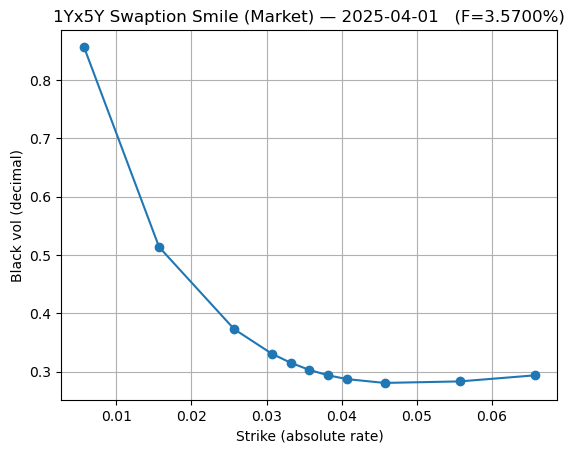

In [24]:
DATE0 = pd.Timestamp("2025-04-01")

# Ensure DATE0 exists; if not (holiday), take the closest previous date
if DATE0 not in smile_vol.index:
    DATE0 = smile_vol.index[smile_vol.index.get_indexer([DATE0], method="pad")[0]]

F0 = float(fwd.loc[DATE0].squeeze())
vols0 = smile_vol.loc[DATE0].astype(float).values  # decimals
K0 = F0 + bp_offsets / 10000.0                    # absolute strikes

# Drop NaNs
mask = np.isfinite(vols0) & np.isfinite(K0)
K0_plot = K0[mask]
vol0_plot = vols0[mask]

plt.figure()
plt.plot(K0_plot, vol0_plot, marker="o", linestyle="-")
plt.title(f"1Yx5Y Swaption Smile (Market) — {DATE0.date()}   (F={F0:.4%})")
plt.xlabel("Strike (absolute rate)")
plt.ylabel("Black vol (decimal)")
plt.grid(True)
plt.show()

In [25]:
def sabr_black_vol(F, K, T, alpha, beta, nu, rho, eps=1e-12):
    """
    Hagan lognormal SABR implied vol.
    Inputs in decimals: F,K as rates; alpha, nu as decimals; T in years; rho in (-1,1)
    Returns Black vol (decimal).
    """
    F = float(F); K = float(K)
    if F <= 0 or K <= 0:
        return np.nan

    one_minus_b = 1.0 - beta
    FK = F * K
    logFK = np.log(F / K)

    # common factor
    FK_beta = (FK)**(0.5 * one_minus_b)

    # z / x(z)
    z = (nu / alpha) * FK_beta * logFK
    # x(z) = log((sqrt(1-2 rho z + z^2) + z - rho)/(1-rho))
    sqrt_term = np.sqrt(max(0.0, 1.0 - 2.0 * rho * z + z * z))
    xz = np.log((sqrt_term + z - rho) / (1.0 - rho))

    # Handle ATM (F ~ K): use limit z/x(z) -> 1
    if abs(logFK) < 1e-10:
        z_over_xz = 1.0
    else:
        z_over_xz = z / (xz + eps)

    # denominator adjustment
    denom = FK_beta * (1.0
        + (one_minus_b**2 / 24.0) * (logFK**2)
        + (one_minus_b**4 / 1920.0) * (logFK**4)
    )

    # time correction term
    term1 = (one_minus_b**2 / 24.0) * (alpha**2) / ((FK)**(one_minus_b))
    term2 = (rho * beta * nu * alpha) / (4.0 * (FK)**(0.5 * one_minus_b))
    term3 = (2.0 - 3.0 * rho**2) * (nu**2) / 24.0
    time_corr = 1.0 + (term1 + term2 + term3) * T

    return (alpha / (denom + eps)) * z_over_xz * time_corr

In [26]:
from scipy.optimize import brentq

def sabr_atm_vol(F, T, alpha, beta, nu, rho):
    # ATM limit of Hagan formula: logFK=0 => z/xz=1, denom=F^(1-beta)
    one_minus_b = 1.0 - beta
    denom = (F**one_minus_b)
    term1 = (one_minus_b**2 / 24.0) * (alpha**2) / (F**(2.0 * one_minus_b))
    term2 = (rho * beta * nu * alpha) / (4.0 * (F**one_minus_b))
    term3 = (2.0 - 3.0 * rho**2) * (nu**2) / 24.0
    time_corr = 1.0 + (term1 + term2 + term3) * T
    return (alpha / denom) * time_corr

def solve_alpha_from_atm(F, T, sigma_atm_mkt, beta, nu, rho):
    """
    Solve for alpha such that SABR ATM vol matches market ATM vol.
    """
    # good initial guess ignoring time_corr:
    alpha0 = sigma_atm_mkt * (F**(1.0 - beta))

    def f(a):
        return sabr_atm_vol(F, T, a, beta, nu, rho) - sigma_atm_mkt

    # bracket around alpha0
    lo = max(1e-8, alpha0 * 0.1)
    hi = max(lo * 10.0, alpha0 * 10.0)

    # Expand bracket if needed
    for _ in range(10):
        if np.sign(f(lo)) != np.sign(f(hi)):
            break
        lo *= 0.5
        hi *= 2.0

    return brentq(f, lo, hi, maxiter=200)

# 1.2 Calibration of SABR with beta = 0.5

Calibration status: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
alpha=0.055371, nu=0.753992, rho=-0.304707, SSE=1.175279e-03


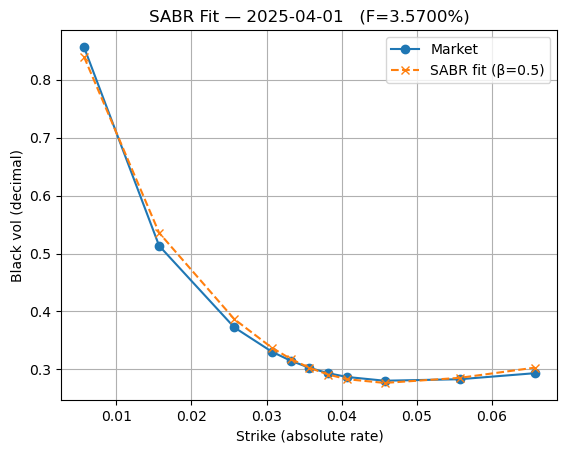

In [28]:
BETA = 0.5
T = 1.0  # 1Y expiry

if 0.0 in bp_offsets:
    sigma_atm_mkt = float(smile_vol.loc[DATE0, smile_vol.columns[np.where(bp_offsets == 0.0)[0][0]]])
else:
    # interpolate in bp space
    sigma_atm_mkt = float(np.interp(0.0, bp_offsets, vols0))

def sabr_obj(x):
    nu, rho = x
    # bounds safety
    if nu <= 0 or not (-0.999 < rho < 0.999):
        return 1e9
    alpha = solve_alpha_from_atm(F0, T, sigma_atm_mkt, BETA, nu, rho)

    model = np.array([sabr_black_vol(F0, k, T, alpha, BETA, nu, rho) for k in K0_plot])
    err = model - vol0_plot
    return float(np.sum(err**2))

x0 = np.array([0.5, -0.2])  # reasonable starter: nu ~ 0.3-1.0, rho often negative for rates
bnds = [(1e-6, 5.0), (-0.999, 0.999)]

res = minimize(sabr_obj, x0, bounds=bnds, method="L-BFGS-B")
nu_hat, rho_hat = res.x
alpha_hat = solve_alpha_from_atm(F0, T, sigma_atm_mkt, BETA, nu_hat, rho_hat)

print("Calibration status:", res.message)
print(f"alpha={alpha_hat:.6f}, nu={nu_hat:.6f}, rho={rho_hat:.6f}, SSE={res.fun:.6e}")

# Plot fit
model_fit = np.array([sabr_black_vol(F0, k, T, alpha_hat, BETA, nu_hat, rho_hat) for k in K0_plot])

plt.figure()
plt.plot(K0_plot, vol0_plot, marker="o", linestyle="-", label="Market")
plt.plot(K0_plot, model_fit, marker="x", linestyle="--", label="SABR fit (β=0.5)")
plt.title(f"SABR Fit — {DATE0.date()}   (F={F0:.4%})")
plt.xlabel("Strike (absolute rate)")
plt.ylabel("Black vol (decimal)")
plt.grid(True)
plt.legend()
plt.show()

# 2.1 SABR ATM vol

In [41]:
# Part 2.0 — forward series in % (use the same forward used in SABR)
F_ts_pct = 100.0 * fwd["atm_fwd"].astype(float)   # forward in %

# Observed ATM Black vol from smile (0bp) in %
sigma_atm_smile_pct = 100.0 * smile_vol[0].astype(float)

# Optional: also compute ATM Black vol from normal-vol series (if vol_1y5y is normal vol in bp)
# sigmaB_% ≈ sigmaN_bp / F_%  (unit-consistent)
vol_bp = vol_1y5y.squeeze().astype(float)
sigma_atm_from_normal_pct = vol_bp / F_ts_pct

# Align all series on common dates
common = F_ts_pct.index.intersection(sigma_atm_smile_pct.index)
common = common.intersection(vol_bp.index)

F_ts_pct = F_ts_pct.loc[common]
sigma_atm_smile_pct = sigma_atm_smile_pct.loc[common]
sigma_atm_from_normal_pct = sigma_atm_from_normal_pct.loc[common]

print("Median F (%):", float(F_ts_pct.median()))
print("Median ATM vol from smile (%):", float(sigma_atm_smile_pct.median()))
print("Median ATM vol from normal approx (%):", float(sigma_atm_from_normal_pct.median()))

Median F (%): 3.56
Median ATM vol from smile (%): 31.53
Median ATM vol from normal approx (%): 31.476323119777156


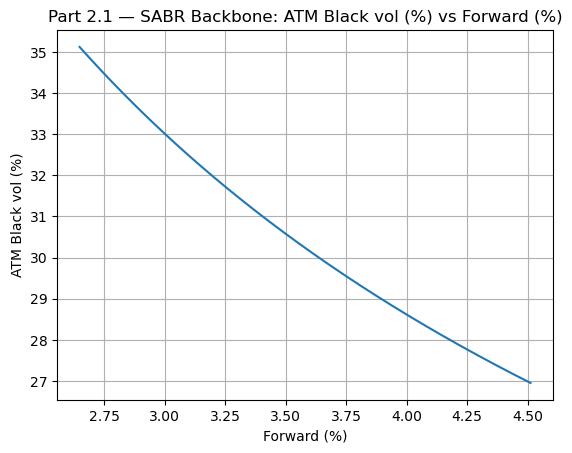

In [42]:
BETA = 0.5
T = 1.0

F_min, F_max = float(F_ts_pct.min()), float(F_ts_pct.max())
F_grid_pct = np.linspace(0.8 * F_min, 1.2 * F_max, 250)

# sabr_atm_vol returns decimal vol → convert to %
sigma_backbone_pct = np.array([
    100.0 * sabr_atm_vol(Fp / 100.0, T, alpha_hat, BETA, nu_hat, rho_hat)
    for Fp in F_grid_pct
])

plt.figure()
plt.plot(F_grid_pct, sigma_backbone_pct)
plt.title("Part 2.1 — SABR Backbone: ATM Black vol (%) vs Forward (%)")
plt.xlabel("Forward (%)")
plt.ylabel("ATM Black vol (%)")
plt.grid(True)
plt.show()

# 2.2 Backbone vs. Empirical Observations

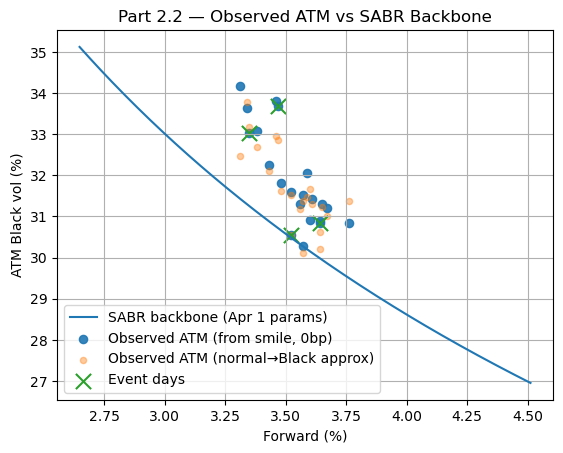

In [43]:
plt.figure()
plt.plot(F_grid_pct, sigma_backbone_pct, label="SABR backbone (Apr 1 params)")

plt.scatter(F_ts_pct.values, sigma_atm_smile_pct.values, s=35, alpha=0.9, label="Observed ATM (from smile, 0bp)")
plt.scatter(F_ts_pct.values, sigma_atm_from_normal_pct.values, s=20, alpha=0.4, label="Observed ATM (normal→Black approx)")

# highlight tariff windows if present
event_dates = pd.to_datetime(["2025-04-02", "2025-04-03", "2025-04-08", "2025-04-09"])
event_dates = [d for d in event_dates if d in common]
if event_dates:
    plt.scatter(F_ts_pct.loc[event_dates].values, sigma_atm_smile_pct.loc[event_dates].values,
                s=120, marker="x", label="Event days")

plt.title("Part 2.2 — Observed ATM vs SABR Backbone")
plt.xlabel("Forward (%)")
plt.ylabel("ATM Black vol (%)")
plt.grid(True)
plt.legend()
plt.show()

# 3.1 Black Delta and SABR Augmented Delta

In [44]:
def black_d1_d2(F, K, sigma, T):
    """Black (lognormal) d1,d2 for rates swaptions; inputs in DECIMALS."""
    srt = sigma * np.sqrt(T)
    d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / srt
    d2 = d1 - srt
    return d1, d2

def black_payer_delta(F, K, sigma, T):
    """
    Payer swaption Black delta w.r.t. forward F, assuming annuity=1.
    If you had annuity A, delta would be A * N(d1); hedge in swap notionals uses N(d1).
    """
    d1, _ = black_d1_d2(F, K, sigma, T)
    return norm.cdf(d1)

def black_vega(F, K, sigma, T):
    """
    Black vega (∂V/∂sigma) assuming annuity=1.
    Units: price change per 1.00 change in vol (decimal).
    """
    d1, _ = black_d1_d2(F, K, sigma, T)
    return F * norm.pdf(d1) * np.sqrt(T)

def sabr_dsigma_dF(F, K, T, alpha, beta, nu, rho, h=1e-4):
    """
    Finite-difference ∂sigma/∂F using SABR implied Black vols.
    h is in rate DECIMALS: h=1e-4 is 1bp.
    Strike K is held FIXED (contract strike).
    """
    sig_p = sabr_black_vol(F + h, K, T, alpha, beta, nu, rho)
    sig_m = sabr_black_vol(F - h, K, T, alpha, beta, nu, rho)
    return (sig_p - sig_m) / (2.0 * h)

In [45]:
BETA = 0.5
T = 1.0  
 
F0 = float(fwd.loc[DATE0, "atm_fwd"])         # decimal
K = F0 + 0.01                                 # +100bp strike, decimal

# Market vol at +100bp from smile (already in DECIMAL vol)
if 100 in smile_vol.columns:
    sigma_mkt = float(smile_vol.loc[DATE0, 100])
else:
    bp_cols = np.array(smile_vol.columns, dtype=float)
    sigma_mkt = float(np.interp(100.0, bp_cols, smile_vol.loc[DATE0].astype(float).values))

# SABR implied vol at (F0,K)
sigma_sabr = float(sabr_black_vol(F0, K, T, alpha_hat, BETA, nu_hat, rho_hat))

# Black delta/vega (market vol)
delta_black_mkt = black_payer_delta(F0, K, sigma_mkt, T)
vega_black_mkt  = black_vega(F0, K, sigma_mkt, T)

# Black delta/vega (SABR vol)
delta_black_sabr = black_payer_delta(F0, K, sigma_sabr, T)
vega_black_sabr  = black_vega(F0, K, sigma_sabr, T)

# SABR dsigma/dF via finite difference (1bp bump)
dsig_dF = sabr_dsigma_dF(F0, K, T, alpha_hat, BETA, nu_hat, rho_hat, h=1e-4)

# Augmented delta (using Black sensitivities evaluated at SABR vol)
delta_aug = delta_black_sabr + vega_black_sabr * dsig_dF

out = pd.DataFrame({
    "F0_%": [100*F0],
    "K_%": [100*K],
    "sigma_mkt_%": [100*sigma_mkt],
    "sigma_sabr_%": [100*sigma_sabr],
    "Delta_Black(mkt vol)": [delta_black_mkt],
    "Delta_Black(SABR vol)": [delta_black_sabr],
    "Vega_Black(SABR vol)": [vega_black_sabr],
    "dSigma_dF (per 1.00 rate)": [dsig_dF],
    "Vega*dSigma_dF (delta correction)": [vega_black_sabr * dsig_dF],
    "Delta_SABR_aug": [delta_aug],
})

display(out)

,F0_%,K_%,sigma_mkt_%,sigma_sabr_%,Delta_Black(mkt vol),Delta_Black(SABR vol),Vega_Black(SABR vol),dSigma_dF (per 1.00 rate),Vega*dSigma_dF (delta correction),Delta_SABR_aug
0,3.57,4.57,28.05,27.670642,0.229609,0.225395,0.010718,-3.324552,-0.035631,0.189764


# 3.2 Decomposition of Correction

In [47]:
def sabr_augmented_delta_decomp(F, K, T, alpha, beta, nu, rho, h=1e-4):
    sig = float(sabr_black_vol(F, K, T, alpha, beta, nu, rho))
    d1_delta = black_payer_delta(F, K, sig, T)
    vega = black_vega(F, K, sig, T)
    ds = sabr_dsigma_dF(F, K, T, alpha, beta, nu, rho, h=h)
    corr = vega * ds
    return sig, d1_delta, vega, ds, corr, d1_delta + corr

bump = 0.005  
F_list = [F0 - bump, F0, F0 + bump]
rows = []

for F_now in F_list:
    sig, dB, v, ds, corr, dA = sabr_augmented_delta_decomp(
        F_now, K, T, alpha_hat, BETA, nu_hat, rho_hat, h=1e-4
    )
    rows.append({
        "F_%": 100*F_now,
        "K_% (fixed)": 100*K,
        "sigma_SABR_%": 100*sig,
        "Delta_Black": dB,
        "Vega_Black": v,
        "dSigma_dF (per 1.00 rate)": ds,
        "Correction = Vega*dSigma_dF": corr,
        "Delta_SABR_aug": dA,
        # Optional: how big is the vol move per 1bp?
        "dSigma per 1bp (vol pts)": 100 * (ds * 1e-4),
    })

decomp = pd.DataFrame(rows).sort_values("F_%").reset_index(drop=True)
display(decomp)

,F_%,K_% (fixed),sigma_SABR_%,Delta_Black,Vega_Black,dSigma_dF (per 1.00 rate),Correction = Vega*dSigma_dF,Delta_SABR_aug,dSigma per 1bp (vol pts)
0,3.07,4.57,29.977232,0.119550,0.006125,-5.872342,-0.035968,0.083582,-0.058723
1,3.57,4.57,27.670642,0.225395,0.010718,-3.324552,-0.035631,0.189764,-0.033246
2,4.07,4.57,26.655669,0.381549,0.015516,-0.781925,-0.012132,0.369417,-0.007819


# 4.1 Smile SABR (beta = 0.5) Calibration

In [48]:
BETA = 0.5
T = 1.0  # 1Y expiry

dates = smile_vol.index.intersection(fwd.index)
dates = dates.sort_values()

bp_offsets = np.array(smile_vol.columns, dtype=float)
bp_offsets.sort()

def K_from_F_offsets(F, offsets_bp):
    return F + offsets_bp / 10000.0

def interp_vol_on_abs_strikes(F_day, vols_by_offset, K_query):
    """
    vols_by_offset: array aligned with bp_offsets (Black vols, DECIMALS)
    Build absolute strike grid for that day and interpolate vols to K_query.
    """
    K_grid = K_from_F_offsets(F_day, bp_offsets)
    # np.interp requires ascending x
    order = np.argsort(K_grid)
    K_grid_sorted = K_grid[order]
    vols_sorted = np.array(vols_by_offset, dtype=float)[order]

    # clip outside range to endpoints
    Kq = np.clip(K_query, K_grid_sorted.min(), K_grid_sorted.max())
    return np.interp(Kq, K_grid_sorted, vols_sorted)

,F,sigma_atm_mkt,alpha,nu,rho,sse
date,,,,,,
2025-04-01,0.0357,0.3028,0.055371,0.753992,-0.304710,0.001175
2025-04-02,0.0352,0.3055,0.055465,0.774908,-0.329124,0.001581
2025-04-03,0.0335,0.3304,0.058379,0.834441,-0.359515,0.003739
2025-04-04,0.0331,0.3418,0.059994,0.846208,-0.361321,0.004459
2025-04-07,0.0346,0.3380,0.060829,0.804205,-0.350302,0.002234
2025-04-08,0.0347,0.3369,0.060665,0.799260,-0.334754,0.002176
2025-04-09,0.0364,0.3084,0.056874,0.734323,-0.254188,0.000905
2025-04-10,0.0367,0.3121,0.057815,0.728327,-0.249777,0.000777
2025-04-11,0.0376,0.3084,0.057853,0.719987,-0.244705,0.000604


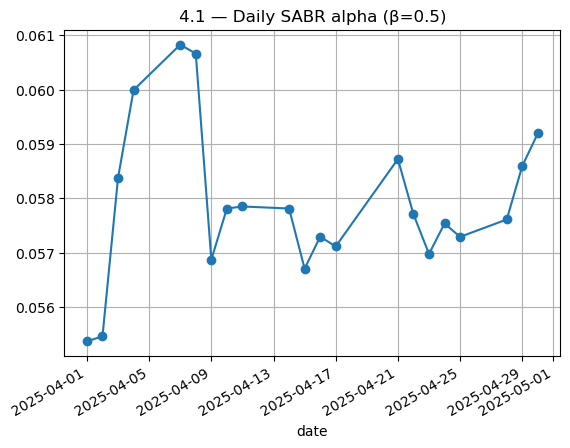

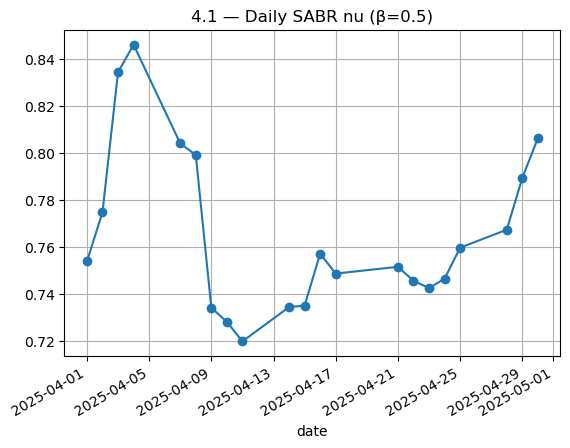

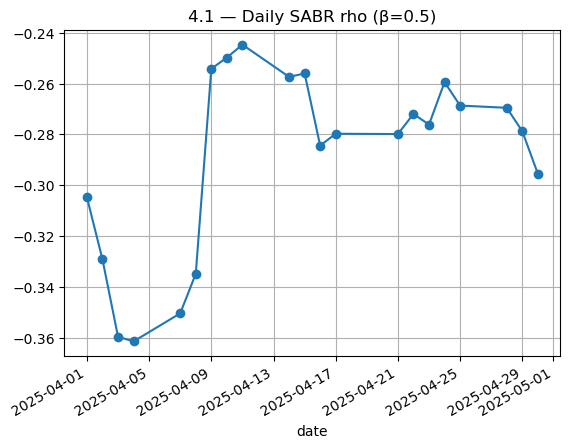

Stability (nu):
count    21.000000
mean      0.765790
std       0.035006
min       0.719987
25%       0.742669
50%       0.753992
75%       0.789462
max       0.846208
Name: nu, dtype: float64

Stability (rho):
count    21.000000
mean     -0.288835
std       0.036859
min      -0.361321
25%      -0.304710
50%      -0.278737
75%      -0.259445
max      -0.244705
Name: rho, dtype: float64


In [52]:
from scipy.optimize import minimize

def calibrate_sabr_one_day(date, x0_list=None):
    F = float(fwd.loc[date, "atm_fwd"])                
    vols = smile_vol.loc[date].astype(float).values     
    K_abs = K_from_F_offsets(F, bp_offsets)

    # market ATM vol (0bp exists in your grid)
    idx0 = np.where(bp_offsets == 0.0)[0][0]
    sigma_atm_mkt = float(vols[idx0])

    # filter (keep finite)
    mask = np.isfinite(vols) & np.isfinite(K_abs)
    K_use = K_abs[mask]
    vols_use = vols[mask]

    # objective over (nu, rho); alpha solved from ATM
    def obj(x):
        nu, rho = x
        if nu <= 0 or not (-0.999 < rho < 0.999):
            return 1e9
        alpha = solve_alpha_from_atm(F, T, sigma_atm_mkt, BETA, nu, rho)
        model = np.array([sabr_black_vol(F, k, T, alpha, BETA, nu, rho) for k in K_use])
        err = model - vols_use
        return float(np.sum(err**2))

    # multi-start (helps avoid occasional weird days)
    if x0_list is None:
        x0_list = [
            (0.30, -0.20),
            (0.60, -0.30),
            (1.00, -0.10),
            (0.50, -0.50),
        ]

    bnds = [(1e-6, 5.0), (-0.999, 0.999)]

    best = None
    for x0 in x0_list:
        res = minimize(obj, np.array(x0), method="L-BFGS-B", bounds=bnds)
        if (best is None) or (res.fun < best.fun):
            best = res

    nu_hat, rho_hat = best.x
    alpha_hat_day = solve_alpha_from_atm(F, T, sigma_atm_mkt, BETA, nu_hat, rho_hat)

    return {
        "date": date,
        "F": F,
        "alpha": alpha_hat_day,
        "nu": nu_hat,
        "rho": rho_hat,
        "sse": float(best.fun),
        "sigma_atm_mkt": sigma_atm_mkt,
    }

rows = [calibrate_sabr_one_day(d) for d in dates]
params_df = pd.DataFrame(rows).set_index("date").sort_index()

display(params_df[["F","sigma_atm_mkt","alpha","nu","rho","sse"]])

# Plots
plt.figure()
params_df["alpha"].plot(marker="o")
plt.title("4.1 — Daily SABR alpha (β=0.5)")
plt.grid(True)
plt.show()

plt.figure()
params_df["nu"].plot(marker="o")
plt.title("4.1 — Daily SABR nu (β=0.5)")
plt.grid(True)
plt.show()

plt.figure()
params_df["rho"].plot(marker="o")
plt.title("4.1 — Daily SABR rho (β=0.5)")
plt.grid(True)
plt.show()

print("Stability (nu):")
print(params_df["nu"].describe())
print("\nStability (rho):")
print(params_df["rho"].describe())

Over the full month, nu ranges from 0.7200 to 0.8462, with its largest day-to-day move between April 8 and April 9 of -0.0649. Nu is fairly stable within a regime, but there is a clear shift at the event window. Rho ranges from -0.3613 to -0.2447 with a large jump from -0.3348 to -0.2542 between April 8 and April 9. Like nu, rho is also moderately stable within a regime, but changes sharply with a regime change.


# 4.2 Backbone next-day ATM prediction

,t,t+1,F_t_%,F_t1_%,ATM_t_%,ATM_t1_%,ATM_pred_t1_%,pred_error_pp
0,2025-04-01,2025-04-02,3.57,3.52,30.28,30.55,30.492916,-0.057084
1,2025-04-02,2025-04-03,3.52,3.35,30.55,33.04,31.309800,-1.730200
2,2025-04-03,2025-04-04,3.35,3.31,33.04,34.18,33.237137,-0.942863
3,2025-04-04,2025-04-07,3.31,3.46,34.18,33.80,33.438220,-0.361780
4,2025-04-07,2025-04-08,3.46,3.47,33.80,33.69,33.751699,0.061699
5,2025-04-08,2025-04-09,3.47,3.64,33.69,30.84,32.900420,2.060420
6,2025-04-09,2025-04-10,3.64,3.67,30.84,31.21,30.714313,-0.495687
7,2025-04-10,2025-04-11,3.67,3.76,31.21,30.84,30.836000,-0.004000
8,2025-04-11,2025-04-14,3.76,3.65,30.84,31.30,31.299133,-0.000867
9,2025-04-14,2025-04-15,3.65,3.60,31.30,30.92,31.515507,0.595507


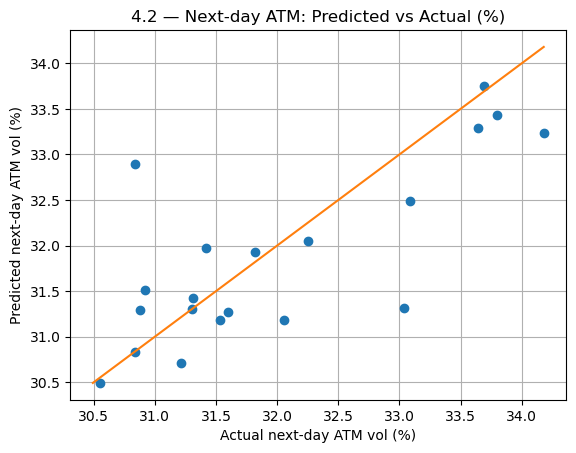

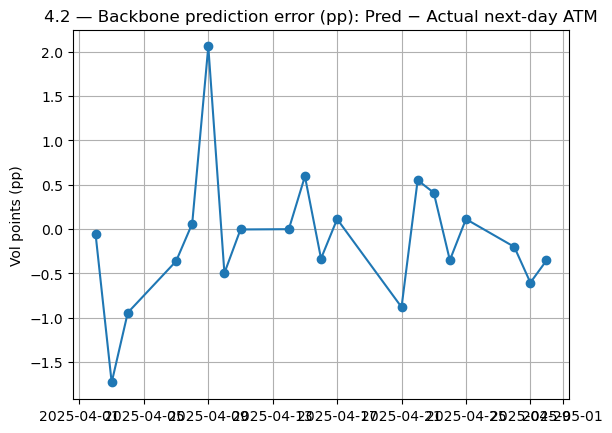

Error summary (pp):
count    20.000000
mean     -0.120355
std       0.747387
min      -1.730200
25%      -0.395257
50%      -0.128658
75%       0.112982
max       2.060420
Name: pred_error_pp, dtype: float64


In [53]:
pairs = []
for i in range(len(params_df.index) - 1):
    t = params_df.index[i]
    t1 = params_df.index[i+1]

    F_t  = float(params_df.loc[t, "F"])
    F_t1 = float(params_df.loc[t1, "F"])

    # actual ATM vols from smile (0bp)
    atm_t  = float(smile_vol.loc[t, 0.0])
    atm_t1 = float(smile_vol.loc[t1, 0.0])

    # day-t backbone prediction at F_{t+1} using day-t parameters
    alpha_t = float(params_df.loc[t, "alpha"])
    nu_t    = float(params_df.loc[t, "nu"])
    rho_t   = float(params_df.loc[t, "rho"])

    atm_pred_t1 = sabr_atm_vol(F_t1, T, alpha_t, BETA, nu_t, rho_t)

    pairs.append({
        "t": t, "t+1": t1,
        "F_t_%": 100*F_t, "F_t1_%": 100*F_t1,
        "ATM_t_%": 100*atm_t,
        "ATM_t1_%": 100*atm_t1,
        "ATM_pred_t1_%": 100*atm_pred_t1,
        "pred_error_pp": 100*(atm_pred_t1 - atm_t1),   # percentage points
    })

pred_df = pd.DataFrame(pairs)
display(pred_df)

plt.figure()
plt.plot(pred_df["ATM_t1_%"].values, pred_df["ATM_pred_t1_%"].values, marker="o", linestyle="None")
mn = min(pred_df["ATM_t1_%"].min(), pred_df["ATM_pred_t1_%"].min())
mx = max(pred_df["ATM_t1_%"].max(), pred_df["ATM_pred_t1_%"].max())
plt.plot([mn, mx], [mn, mx])
plt.title("4.2 — Next-day ATM: Predicted vs Actual (%)")
plt.xlabel("Actual next-day ATM vol (%)")
plt.ylabel("Predicted next-day ATM vol (%)")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(pred_df["t+1"], pred_df["pred_error_pp"], marker="o")
plt.title("4.2 — Backbone prediction error (pp): Pred − Actual next-day ATM")
plt.ylabel("Vol points (pp)")
plt.grid(True)
plt.show()

print("Error summary (pp):")
print(pred_df["pred_error_pp"].describe())

In [54]:
err = pred_df["pred_error_pp"]  # pred - actual, in vol points

rmse = np.sqrt((err**2).mean())
corr = pred_df["ATM_t1_%"].corr(pred_df["ATM_pred_t1_%"])  # Pearson corr

mae = err.abs().mean()   # also useful
print(rmse, corr, mae)

0.7383384628252436 0.7675143946582724 0.5109751049594405


The mean and median errors of ~-0.12 pp and ~-0.13 pp, respectively, show a slight underprediction of vol points by the backbone. The RMSE and Correlation values of ~0.74 and ~0.77, respectively, show that the backbone does capture a significant portion of daily ATM moves. The two significant mispredictions occur on April 2 to April 3 and April 8 to April 9. On April 2 to April 3, the tariff shock caused a volatility jump that was underpredicted by the backbone's level effects. Similarly, on April 8 to April 9, the model expected volatility to remain high due to the level and thus overpredicts when the vol normalization occurs. 

In conclusion, the SABR backbone performed well as a first-order mapping from rate level to ATM implied vol within regimes. However, during shocks and subsequent reversals, the movement of ATM vol far exceeded the amount predictable by level effects, resulting in large forecast errors. 

# 4.3 Per-pair RMSE and event-day plots

,t,t+1,rmse_black_%,rmse_sabr_%
0,2025-04-01,2025-04-02,0.864666,1.528377
1,2025-04-02,2025-04-03,3.803573,3.343667
2,2025-04-03,2025-04-04,1.555826,2.288333
3,2025-04-04,2025-04-07,4.885929,4.161567
4,2025-04-07,2025-04-08,0.444005,1.326545
5,2025-04-08,2025-04-09,5.793519,4.181176
6,2025-04-09,2025-04-10,0.607846,0.717144
7,2025-04-10,2025-04-11,1.306708,1.018408
8,2025-04-11,2025-04-14,0.696594,1.213197
9,2025-04-14,2025-04-15,0.475107,0.969407


RMSE summary across all pairs (in vol %, i.e. vol points):
       rmse_black_%  rmse_sabr_%
count     20.000000    20.000000
mean       1.488589     1.690758
std        1.505984     1.061617
min        0.444005     0.717144
25%        0.690354     0.955558
50%        0.886107     1.419379
75%        1.339040     1.973247
max        5.793519     4.181176


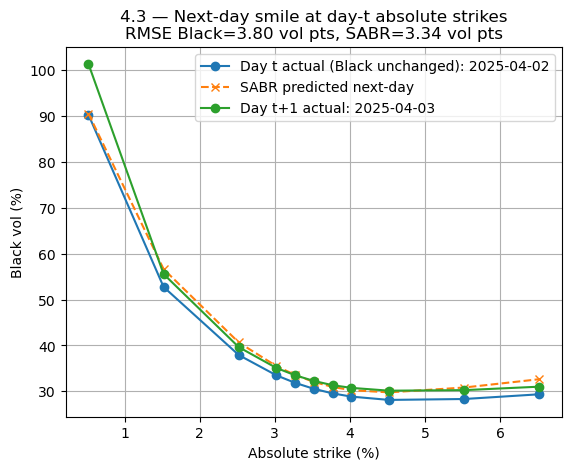

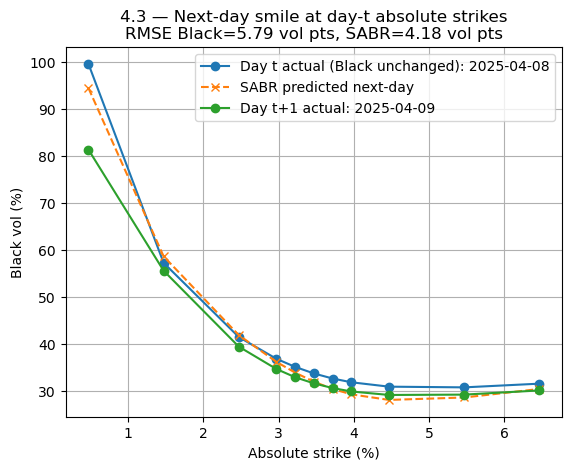

In [51]:
def predict_next_smile_for_pair(t, t1):
    F_t  = float(params_df.loc[t, "F"])
    F_t1 = float(params_df.loc[t1, "F"])

    vols_t  = smile_vol.loc[t].astype(float).values        # by offsets (decimals)
    vols_t1 = smile_vol.loc[t1].astype(float).values       # by offsets (decimals)

    # absolute strikes from day t
    K_eval = K_from_F_offsets(F_t, bp_offsets)

    # actual next-day vols at those absolute strikes (interpolate day t+1 curve)
    vols_t1_at_Keval = interp_vol_on_abs_strikes(F_t1, vols_t1, K_eval)

    # Black unchanged smile at day-t absolute strikes = just today's vols at those strikes
    black_pred = vols_t.copy()

    # SABR predicted: keep nu_t, rho_t; re-solve alpha_{t+1} using actual ATM_{t+1}
    nu_t  = float(params_df.loc[t, "nu"])
    rho_t = float(params_df.loc[t, "rho"])

    atm_t1 = float(smile_vol.loc[t1, 0.0])
    alpha_t1 = solve_alpha_from_atm(F_t1, T, atm_t1, BETA, nu_t, rho_t)

    sabr_pred = np.array([sabr_black_vol(F_t1, k, T, alpha_t1, BETA, nu_t, rho_t) for k in K_eval])

    # RMSE (decimals)
    rmse_black = float(np.sqrt(np.mean((black_pred - vols_t1_at_Keval)**2)))
    rmse_sabr  = float(np.sqrt(np.mean((sabr_pred  - vols_t1_at_Keval)**2)))

    return K_eval, vols_t, vols_t1_at_Keval, black_pred, sabr_pred, rmse_black, rmse_sabr

# RMSE across all consecutive pairs
rmse_rows = []
for i in range(len(dates) - 1):
    t, t1 = dates[i], dates[i+1]
    _, _, _, _, _, rb, rs = predict_next_smile_for_pair(t, t1)
    rmse_rows.append({"t": t, "t+1": t1, "rmse_black_%": 100*rb, "rmse_sabr_%": 100*rs})

rmse_df = pd.DataFrame(rmse_rows)
display(rmse_df)

print("RMSE summary across all pairs (in vol %, i.e. vol points):")
print(rmse_df[["rmse_black_%","rmse_sabr_%"]].describe())

# Helper to pick nearest available dates (pad)
def nearest_date(d):
    d = pd.Timestamp(d)
    return dates[dates.get_indexer([d], method="pad")[0]]

event_pairs = [
    (nearest_date("2025-04-02"), nearest_date("2025-04-03")),
    (nearest_date("2025-04-08"), nearest_date("2025-04-09")),
]

for (t, t1) in event_pairs:
    K_eval, vols_t, vols_t1_at_Keval, black_pred, sabr_pred, rb, rs = predict_next_smile_for_pair(t, t1)

    plt.figure()
    plt.plot(100*K_eval, 100*vols_t, marker="o", label=f"Day t actual (Black unchanged): {t.date()}")
    plt.plot(100*K_eval, 100*sabr_pred, marker="x", linestyle="--", label="SABR predicted next-day")
    plt.plot(100*K_eval, 100*vols_t1_at_Keval, marker="o", linestyle="-", label=f"Day t+1 actual: {t1.date()}")

    plt.title(f"4.3 — Next-day smile at day-t absolute strikes\nRMSE Black={100*rb:.2f} vol pts, SABR={100*rs:.2f} vol pts")
    plt.xlabel("Absolute strike (%)")
    plt.ylabel("Black vol (%)")
    plt.grid(True)
    plt.legend()
    plt.show()